In [1]:
import numpy as np
from nn.nn import NeuralNetwork
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits

### **Load in Digits Database**

In [2]:
digits = load_digits()
feature_range = 16.0 # from scikit docs: image pixel values range from 0-16
X = digits.data / feature_range # normalizing pixel values to between 0 and 1 (for training stability)

# splitting images into train and validation
validation_prop = 0.20
num_samples = X.shape[0]
validation_size = int(validation_prop * num_samples)
print(f"Training set has {num_samples-validation_size} images and validation set has {validation_size} images")

random_indices = np.random.permutation(num_samples) # randomly shuffle all the indices...
val_idx = random_indices[:validation_size] # ...then pick a proportion of indicies for validation
train_idx = random_indices[validation_size:]

X_train = X[train_idx]
X_val = X[val_idx]

Training set has 1438 images and validation set has 359 images


### **Define and Train Autoencoder Model**

*Hyperparameter Choices:* 
Admittedly, some of the hyperparameter choices came from running the model a few times and seeing what caused training/validation loss and validation error to trend downwards, and the decoded images to better match the original images. However, I generally made the choice to have a learning rate of 0.01 to allow semi-fast convergence without making learning rate so large that the model would keep missing convergence. For batch size, I generally wanted to choose a size that would allow the model to train on enough examples for every given batch, without requiring too much computation, and thus, 128 seemed like a sufficient enough number to get a pretty good portion, given the size of the training and validation sets. As for epochs, I just ensured to set them high enough so that I could see the training and validation loss to plateau, without seeing a rise in loss that would suggest overfitting. 

In [3]:
autoencoder_arch =  [
    {"input_dim": 64, "output_dim": 16, "activation": "relu"},
    {"input_dim": 16, "output_dim": 64, "activation": "sigmoid"}
]

digit_autoencoder = NeuralNetwork(
    nn_arch = autoencoder_arch,
    lr = 0.01,
    seed = 29,
    batch_size = 128,
    epochs = 5000,
    loss_function = "mse"
)

In [4]:
# because this an autoencoder, the target output is the original input
train_losses, val_losses = digit_autoencoder.fit(X_train, X_train,
                                                 X_val, X_val)

### **Visualize Training and Validation Loss**

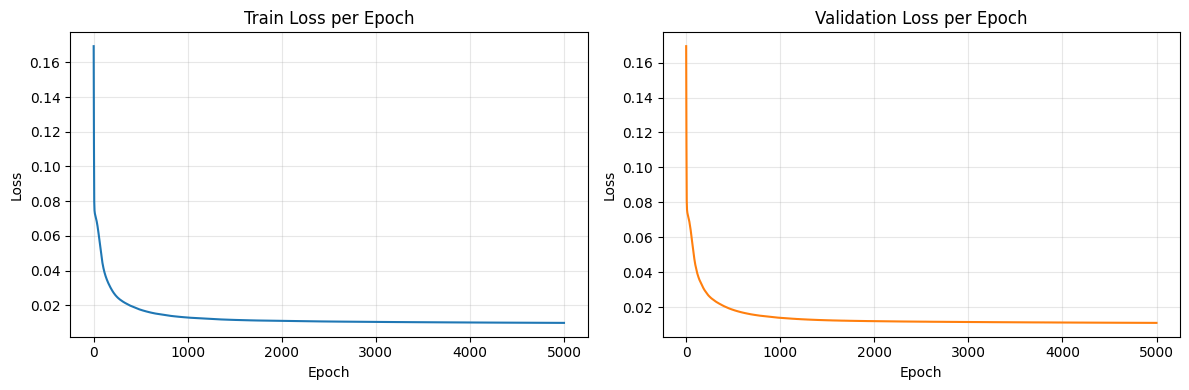

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(train_losses, color="tab:blue")
axes[0].set_title("Train Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_losses, color="tab:orange")
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Quantify Average Reconstruction Error in Validation Set**

In [6]:
X_val_output = digit_autoencoder.predict(X_val)

val_error = digit_autoencoder._mean_squared_error(X_val, X_val_output)
print(f"Average Reconstruction Error in Validation Set: {round(val_error, 4)}")

Average Reconstruction Error in Validation Set: 0.0109


### **Visualize Example Images of Model Decoded Outputs**

Just a bonus visualization to help me understand how well the autoencoder is working

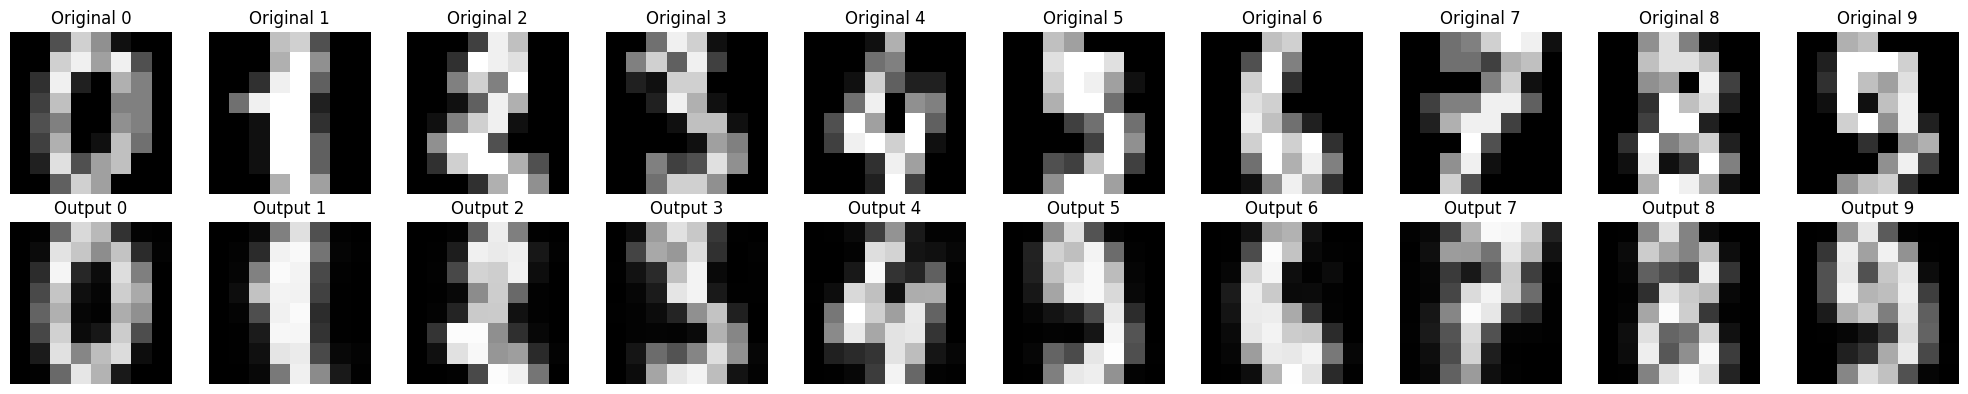

In [10]:
num_examples = 10
original = digits.images[:num_examples]
X_example = X[:num_examples]

decoded = digit_autoencoder.predict(X_example)
decoded = np.asarray(decoded).reshape(num_examples, 8, 8) # reshaping output 64 vector into 8x8
decoded = feature_range * decoded # un-normalizing pixel values

fig, axes = plt.subplots(2, num_examples, figsize=(2 * num_examples, 4))

for i in range(num_examples):
    axes[0, i].imshow(original[i], cmap="gray", vmin=0, vmax=16)
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Original {i}")

    axes[1, i].imshow(decoded[i], cmap="gray", vmin=0, vmax=16)
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Output {i}")

plt.tight_layout()
plt.show()